# 10 -- Pelne obliczenia produkcji (integracja modeli)

Ten notebook **zlozy w jedno** wszystkie modele z notebookow 05-09:

1. **Hydrologia** (nb 04, 05) -- sredni rok uporzadkowany Q i H
2. **Straty hydrauliczne** (nb 06) -- `loss_fns`, spad netto $H_{net}(Q)$
3. **Turbina** (nb 07) -- typ, n_turbin, $\eta_t(Q/Q_{des})$, rozdzial przeplywu
4. **Generator** (nb 08) -- $\eta_g(P/P_n)$ zalezne od obciazenia
5. **Koszty** (nb 09) -- inwestycja, O&M, NPV, LCOE

Integrator: `src/production.py` → `compute_power()`.

**Cel:** porownac realny model z uproszczonym $\eta_{total} = const$ z nb 05.

---

## Modul `src/production.py`

**Prompt do LLM tworzacy ten modul:**
> *"Stworz modul src/production.py jako warstwe integrujaca: funkcja
> `compute_power(Q_sorted, H_gross, Q_design, n_turbines, turbine_type, loss_fns,
> H_design, gen_k_cu, gen_k_fe, gen_k_mech, rho, g)` ktora dla kazdego dnia
> sredniego roku uporzadkowanego: (1) rozdziela przeplyw na turbiny,
> (2) liczy straty hydrauliczne, (3) sprawnosc turbiny, (4) moc na wale,
> (5) sprawnosc generatora (per-unit), (6) moc elektryczna, (7) energie dobowa.
> Zwraca DataFrame z wszystkimi kolumnami posrednimi.
> Dodatkowo funkcja `compute_power_constant_eta()` do replikacji uproszczenia z nb05."*

**Funkcje w module:**
- `compute_power(...)` -- pelny model (losses + var η_t + var η_g)
- `compute_power_constant_eta(...)` -- model staly (jak w nb 05) dla porownania
- `annual_energy(df)`, `capacity_factor(df, P_rated)`, `operating_hours(df)`, `average_efficiency(df)` -- metryki podsumowujace

## Konfiguracja

**Prompt do LLM:**
> *"Napisz kod konfiguracji notebooka 10: zaladuj `compute_power` i metryki
> z `src/production`, `TURBINE_CATALOG` z `src/turbine`, funkcje strat
> z `src/losses`, funkcje kosztow z `src/costs`, oraz hydrologie
> (`average_sorted_year`, `filter_incomplete_years`, `transfer_flow_between`)
> i `imgw_data.load_processed`."*

**Uzyte moduly/funkcje:** `src.production`, `src.turbine`, `src.losses`, `src.costs`, `src.hydrology`, `src.imgw_data`, `src.watershed`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.imgw_data import load_processed
from src.hydrology import (
    average_sorted_year,
    interpolate_q_to_location,
    environmental_flow,
)
from src.watershed import get_station_area, find_gauge, get_catchment_area

from src.losses import (
    trash_rack_loss, pipe_friction_loss, minor_loss, net_head,
)
from src.turbine import TURBINE_CATALOG, runner_diameter, rotational_speed, synchronous_speed
from src.production import (
    compute_power, compute_power_constant_eta,
    annual_energy, capacity_factor, operating_hours, average_efficiency,
)
from src.costs import total_investment, economic_analysis, EUR_PLN_RATE

pd.set_option('display.max_columns', 15)
print('Moduly zaladowane.')

Moduly zaladowane.


---
## Krok 1: Sredni rok uporzadkowany Q i H

Powtarzamy w skrocie procedure z nb 05: interpolujemy przeplyw z dwoch wodowskazow
do lokalizacji EW, budujemy sredni rok uporzadkowany dla Q i dla stanu wody.

**Prompt do LLM:**
> *"Wczytaj dane z `data/processed/daily_hydro_clean.parquet`. Zinterpoluj przeplyw
> Q_ew z gauges Brzeg Dolny (upstream) i Malczyce (downstream) metoda potegowa
> wg pol zlewni. Wyznacz sredni rok uporzadkowany Q_sorted oraz H_net_sorted
> z modelu spadu (Hsa = H_stage + level_avg - level_day)."*

**Uzyte funkcje:** `load_processed`, `filter_incomplete_years`, `average_sorted_year`, `get_station_area`, `find_gauge`, `get_catchment_area`.

In [2]:
# Wczytaj dane (juz przefiltrowane w nb 02 — bez lat niekompletnych/powodziowych)
df = load_processed('../data/processed/daily_hydro_clean.parquet')

STATION_UP = '151160170'    # Brzeg Dolny (upstream)
STATION_DOWN = '151160150'  # Malczyce (downstream)

A_UP = get_station_area(STATION_UP)
A_DOWN = get_station_area(STATION_DOWN)
gauge_up = find_gauge(STATION_UP)
gauge_down = find_gauge(STATION_DOWN)
lat_ew = (gauge_up['lat'] + gauge_down['lat']) / 2
lng_ew = (gauge_up['lng'] + gauge_down['lng']) / 2
A_TARGET = get_catchment_area(lat_ew, lng_ew, label='EW')

# Interpolacja Q gauge -> EW (wspolna funkcja z src.hydrology — jeden punkt definicji
# wspoldzielony z nb 03 i nb 05)
df_up = df[df['station_id'] == STATION_UP][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_up', 'water_level_cm': 'level_up'})
df_down = df[df['station_id'] == STATION_DOWN][['date', 'discharge_m3s', 'water_level_cm']].rename(
    columns={'discharge_m3s': 'Q_down', 'water_level_cm': 'level_down'})
df_ew = df_up.merge(df_down, on='date', how='inner').dropna()
df_ew = df_ew[(df_ew['Q_up'] > 0) & (df_ew['Q_down'] > 0)].copy()
df_ew['Q_ew'] = interpolate_q_to_location(
    Q_up=df_ew['Q_up'].values, Q_down=df_ew['Q_down'].values,
    A_up=A_UP, A_down=A_DOWN, A_target=A_TARGET,
    method='daily_n',
)

# Sredni rok uporzadkowany Q (dane juz przefiltrowane w nb 02 — nie filtrujemy ponownie)
df_q = pd.DataFrame({'station_id': 'EW', 'date': df_ew['date'], 'discharge_m3s': df_ew['Q_ew']})
avg_year_q = average_sorted_year(df_q, 'EW')
Q_sorted = avg_year_q['mean'].values

# Sredni rok uporzadkowany stanu wody (wodowskaz dolny — Malczyce)
avg_year_lvl = average_sorted_year(df, STATION_DOWN, column='water_level_cm')
level_sorted = avg_year_lvl['mean'].values / 100.0  # m
level_avg = (df[df['station_id'] == STATION_DOWN]['water_level_cm'].dropna() / 100.0).mean()

# Spad netto (gross): zmienia sie wg odchylenia stanu wody od sredniego
H_STAGE = 6.0  # spad brutto na stopniu wodnym
H_gross = np.maximum(H_STAGE + (level_avg - level_sorted), 0.0)

# Przeplyw nienaruszalny (Polskie prawo wodne 2017) — Q90% jako baseline
Q_ENV = environmental_flow(Q_sorted, method='Q90')

print(f'Zlewnia EW = {A_TARGET:.0f} km2')
print(f'Sredni rok uporzadkowany: {len(Q_sorted)} dni')
print(f'  Q: min={Q_sorted.min():.1f}, mean={Q_sorted.mean():.1f}, max={Q_sorted.max():.1f} m3/s')
print(f'  H_gross: min={H_gross.min():.2f}, max={H_gross.max():.2f} m (H_stage={H_STAGE} m)')
print(f'  Q_env (Q90%, biologiczny): {Q_ENV:.2f} m3/s — rezerwowany dla rzeki, nieprzeplywa turbiny')

Zlewnia EW = 26545 km2
Sredni rok uporzadkowany: 365 dni
  Q: min=34.7, mean=128.1, max=441.1 m3/s
  H_gross: min=2.94, max=7.20 m (H_stage=6.0 m)
  Q_env (Q90%, biologiczny): 58.74 m3/s — rezerwowany dla rzeki, nieprzeplywa turbiny


---
## Krok 2: Konfiguracja drogi wodnej (straty hydrauliczne)

Definiujemy `loss_fns` -- liste funkcji $Q \\to \\Delta H$. Tutaj instalacja
rurociagowa typowa dla niskiego spadu (jak w nb 06).

**Prompt do LLM:**
> *"Zdefiniuj `loss_fns` dla naszej drogi wodnej: krata, krotki rurociag (D=2.5m,
> L=15m), wlot zaokraglony, jedno kolano, zasuwa motylkowa, spirala, rura ssawna."*

**Uzyte funkcje:** `trash_rack_loss`, `pipe_friction_loss`, `minor_loss`.

In [ ]:
# KONFIGURACJA DROGI WODNEJ EW — krotki kanal otwarty (typowa dla niskospadowych RoR)
# UWAGA: compute_power przekazuje do loss_fns Q_used = n_active * Q_per_turb (CALKOWITY przeplyw
# przez plant). Wszystkie powierzchnie sa SUMARYCZNE — krata 1, kanal 1, ale spirale i rury
# ssawne to N rownoleglych przekrojow → A = n_turbines × A_per_turbine.
N_TURBINES_LOSS = 2
A_RACK_TOTAL = 30.0           # m2 (krata na ujeciu glownym, v < 1 m/s przy Q_total max)
A_SPIRAL_PER = 3.5            # m2 na turbine
A_RUNNER_PER = 6.0            # m2 na turbine (D1 ≈ 2.8 m dla Kaplana)

def manning_loss(Q, b, h, L, n_manning=0.013):
    """Strata Manninga w kanale prostokatnym (uzywana jako loss_fn)."""
    Q = np.asarray(Q, dtype=float)
    A_ch = b * h
    P_wet = b + 2 * h
    R = A_ch / P_wet
    v = Q / A_ch
    return (n_manning * v / R ** (2/3)) ** 2 * L

loss_fns = [
    lambda Q: trash_rack_loss(Q, A_rack=A_RACK_TOTAL, bar_width=0.012, bar_spacing=0.05),
    lambda Q: manning_loss(Q, b=10.0, h=2.5, L=30.0, n_manning=0.013),   # kanal betonowy
    lambda Q: minor_loss(Q, A=25.0, xi=0.10),                            # wlot do kanalu/zwezki
    lambda Q: minor_loss(Q, A=N_TURBINES_LOSS * A_SPIRAL_PER, xi=0.10),  # spirale wszystkich turbin (parallel)
    lambda Q: minor_loss(Q, A=N_TURBINES_LOSS * A_RUNNER_PER, xi=0.25),  # rury ssawne wszystkich turbin
]

# Wykres H_gross vs H_net w zakresie naszego Q_total (0..50 m3/s)
Q_test = np.linspace(1, 55, 200)
H_net_test = net_head(H_STAGE, Q_test, loss_fns)
dH_test = H_STAGE - H_net_test

fig = make_subplots(rows=1, cols=2, subplot_titles=[
    'H_brutto vs H_netto (Q calkowite plantu)',
    'Sklad strat przy Q_total = 46.8 m3/s'])

fig.add_hline(y=H_STAGE, line_dash='dash', line_color='gray',
    annotation_text=f'H_brutto = {H_STAGE} m', row=1, col=1)
fig.add_trace(go.Scatter(x=Q_test, y=H_net_test, mode='lines',
    line=dict(color='royalblue', width=2.5), name='H_netto(Q)'), row=1, col=1)
fig.add_trace(go.Scatter(x=Q_test, y=dH_test, mode='lines',
    line=dict(color='firebrick', width=2), name='Suma strat'), row=1, col=1)

# Sklad strat w punkcie projektowym
Q_design_total = 46.8
labels = ['Krata', 'Kanal (Manning)', 'Wlot', 'Spirale (2)', 'Rury ssawne (2)']
values = [float(fn(Q_design_total)) for fn in loss_fns]
fig.add_trace(go.Bar(x=labels, y=[v*100 for v in values],
    marker_color='royalblue', showlegend=False), row=1, col=2)

fig.update_xaxes(title_text='Q calkowite [m3/s]', row=1, col=1)
fig.update_xaxes(title_text='Komponent', row=1, col=2)
fig.update_yaxes(title_text='H [m]', range=[0, H_STAGE+0.3], row=1, col=1)
fig.update_yaxes(title_text='Strata [cm]', row=1, col=2)
fig.update_layout(height=420, hovermode='x unified',
    title='Droga wodna EW — kanal otwarty (2 turbiny rownolegle)')
fig.show()

print(f'Sumaryczna strata przy Q_total = {Q_design_total} m3/s: '
      f'{sum(values)*100:.1f} cm ({sum(values)/H_STAGE*100:.1f}% spadu brutto)')

---
## Krok 3: Wybor turbiny i punkt projektowy

Wybieramy typ turbiny, liczbe agregatow i $Q_{design}$ na turbine.
Punkt projektowy to **dzien instalacyjny** na krzywej uporzadkowanej.
Tutaj startujemy od $d_{install} = 70$ (~19% przekroczenia) — taki sam jak w arkuszu WPE_2.xlsm.

**Prompt do LLM:**
> *"Skonfiguruj wybor: Kaplan, 2 turbiny, dzien instalacyjny 70. Oblicz
> Q_design na turbine i wymiarowanie wirnika (D1, n)."*

**Uzyte funkcje:** `TURBINE_CATALOG`, `runner_diameter`, `rotational_speed`, `synchronous_speed`.

In [4]:
# Konfiguracja turbinowa
turbine_type = TURBINE_CATALOG['kaplan']
N_TURBINES = 2
INSTALL_DAY = 70

# Q_design (na turbine): calkowite Q na dniu instalacyjnym / liczba turbin
Q_total_design = float(Q_sorted[INSTALL_DAY - 1])
Q_design = Q_total_design / N_TURBINES
H_design = float(H_gross[INSTALL_DAY - 1])  # spad na dniu projektowym

# Wymiarowanie wirnika (jednego)
D1 = runner_diameter(Q_design, H_design, turbine_type)
n_raw = rotational_speed(H_design, D1, turbine_type)
n_sync, poles = synchronous_speed(n_raw)

print(f'Turbina: {turbine_type.name_pl}, liczba: {N_TURBINES}')
print(f'Dzien instalacyjny: {INSTALL_DAY} ({INSTALL_DAY/365*100:.1f}% przekroczenia)')
print(f'Q_total_design = {Q_total_design:.2f} m3/s')
print(f'Q_design/turbine = {Q_design:.2f} m3/s')
print(f'H_design = {H_design:.2f} m')
print(f'D1 = {D1:.3f} m')
print(f'n = {n_raw:.0f} obr/min -> n_sync = {n_sync:.0f} obr/min ({poles} biegunow)')

Turbina: Kaplan (podwojnie regulowana), liczba: 2
Dzien instalacyjny: 70 (19.2% przekroczenia)
Q_total_design = 178.35 m3/s
Q_design/turbine = 89.17 m3/s
H_design = 5.33 m
D1 = 5.674 m
n = 64 obr/min -> n_sync = 100 obr/min (60 biegunow)


---
## Krok 4: Pelne obliczenie produkcji

Teraz puszczamy wszystko przez `compute_power()` -- integrator wykonuje
po kolei: rozdzial → straty → η_t(Q) → moc na wale → η_g(P/Pn) (per-unit) → energia.

**Prompt do LLM:**
> *"Wywolaj `compute_power(Q_sorted, H_gross, Q_design, n_turbines=2, turbine_type=Kaplan,
> loss_fns=loss_fns, H_design=H_design)`. Wyswietl pierwsze 5 wierszy DataFrame
> oraz metryki: energia roczna [MWh], capacity factor, dni pracy, srednia η_t i η_g."*

**Uzyte funkcje:** `compute_power`, `annual_energy`, `capacity_factor`, `operating_hours`, `average_efficiency`.

In [5]:
# Pelne obliczenie produkcji (z przeplywem nienaruszalnym Q_env)
result = compute_power(
    Q_sorted=Q_sorted,
    H_gross=H_gross,
    Q_design=Q_design,
    n_turbines=N_TURBINES,
    turbine_type=turbine_type,
    loss_fns=loss_fns,
    H_design=H_design,
    Q_env=Q_ENV,
)

# Metryki
E_MWh = annual_energy(result)
P_rated_unit_kW = 998 * 9.81 * Q_design * H_design * turbine_type.eta_peak / 1000.0
P_rated_total_kW = P_rated_unit_kW * N_TURBINES
CF = capacity_factor(result, P_rated_total_kW)
oh = operating_hours(result)
eta_avg = average_efficiency(result)

print(f'=== Pelny model produkcji (Q_env={Q_ENV:.2f} m3/s) ===')
print(f'  Moc znamionowa (caly zaklad): {P_rated_total_kW:.0f} kW '
      f'({N_TURBINES} x {P_rated_unit_kW:.0f} kW)')
print(f'  Energia roczna:               {E_MWh:.0f} MWh/rok')
print(f'  Wspolczynnik wykorzystania:   {CF*100:.1f}%')
print(f'  Dni pracy:                    {oh} / {len(Q_sorted)}')
print(f'  Srednia η_t (wazona energia): {eta_avg["eta_t_avg"]:.3f}')
print(f'  Srednia η_g (wazona energia): {eta_avg["eta_g_avg"]:.3f}')
print(f'  Srednia η_t · η_g:            {eta_avg["eta_total_avg"]:.3f}')
print()
print('Pierwsze 5 wierszy DataFrame:')
result.head()

=== Pelny model produkcji (Q_env=58.74 m3/s) ===
  Moc znamionowa (caly zaklad): 8558 kW (2 x 4279 kW)
  Energia roczna:               350 MWh/rok
  Wspolczynnik wykorzystania:   0.5%
  Dni pracy:                    48 / 365
  Srednia η_t (wazona energia): 0.664
  Srednia η_g (wazona energia): 0.854
  Srednia η_t · η_g:            0.567

Pierwsze 5 wierszy DataFrame:


,day,pct,Q_avail,Q_for_turbine,Q_per_turbine,n_active,Q_used,H_gross,H_net,eta_t,P_shaft_kW,eta_g,P_el_kW,E_kWh
0,1,0.27,441.064,382.328,89.1735,2,178.347,2.936923,0.0,0.91,0.0,0.0,0.0,0.0
1,2,0.55,428.916,370.180,89.1735,2,178.347,3.024003,0.0,0.91,0.0,0.0,0.0,0.0
2,3,0.82,412.243,353.507,89.1735,2,178.347,3.172553,0.0,0.91,0.0,0.0,0.0,0.0
3,4,1.10,395.965,337.229,89.1735,2,178.347,3.300863,0.0,0.91,0.0,0.0,0.0,0.0
4,5,1.37,378.685,319.949,89.1735,2,178.347,3.429253,0.0,0.91,0.0,0.0,0.0,0.0


### Wykres produkcji vs procent przekroczenia

**Prompt do LLM:**
> *"Narysuj 4 wykresy w siatce 2x2: (1) Q dostepne i Q uzyte, (2) sprawnosci η_t i η_g,
> (3) liczba aktywnych turbin, (4) moc elektryczna. Wszystko vs procent przekroczenia."*

In [ ]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=['Q [m3/s] (dostepne vs uzyte)', 'Sprawnosci η_t, η_g',
                    'Liczba aktywnych turbin', 'Moc elektryczna [kW]'],
    vertical_spacing=0.13, horizontal_spacing=0.10)

pct = result['pct'].values
Q_total_design = Q_design * N_TURBINES  # cap przy ktorym plant pracuje na pelnej mocy

# Maski: 'plant pracuje' (n_active > 0) — uzywane do NaN-gap eta i P
running = result['n_active'].values > 0
eta_t_plot = np.where(running, result['eta_t'].values, np.nan)
eta_g_plot = np.where(running, result['eta_g'].values, np.nan)

# (1) Q
fig.add_trace(go.Scatter(x=pct, y=result['Q_avail'], mode='lines',
    name='Q dostepne', line=dict(color='gray', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=pct, y=result['Q_used'], mode='lines',
    name='Q uzyte (= Q_avail − Q_env, cap n×Q_des)', line=dict(color='royalblue', width=2)), row=1, col=1)
# Referencje
fig.add_hline(y=Q_total_design, line=dict(color='green', dash='dot', width=1),
    annotation_text=f'Q_total_design = {Q_total_design:.1f} m3/s', row=1, col=1)
fig.add_hline(y=Q_ENV, line=dict(color='red', dash='dot', width=1),
    annotation_text=f'Q_env (Q90%) = {Q_ENV:.1f} m3/s', row=1, col=1)

# (2) sprawnosci — NaN-gap gdy plant stoi
fig.add_trace(go.Scatter(x=pct, y=eta_t_plot, mode='lines',
    name='η_t', connectgaps=False, line=dict(color='firebrick', width=2)), row=1, col=2)
fig.add_trace(go.Scatter(x=pct, y=eta_g_plot, mode='lines',
    name='η_g', connectgaps=False, line=dict(color='green', width=2)), row=1, col=2)

# (3) n_active (step)
fig.add_trace(go.Scatter(x=pct, y=result['n_active'], mode='lines',
    name='n_active', line=dict(color='purple', width=2, shape='hv'),
    showlegend=False), row=2, col=1)

# (4) P_el
fig.add_trace(go.Scatter(x=pct, y=result['P_el_kW'], mode='lines',
    name='P_el [kW]', fill='tozeroy',
    line=dict(color='darkorange', width=1.5), showlegend=False), row=2, col=2)

fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=2, col=1)
fig.update_xaxes(title_text='Prawdopodobienstwo przekroczenia [%]', row=2, col=2)
fig.update_yaxes(title_text='Q [m3/s]', row=1, col=1)
fig.update_yaxes(title_text='η [-]', range=[0, 1], row=1, col=2)
fig.update_yaxes(title_text='liczba turbin', range=[-0.2, N_TURBINES + 0.3], row=2, col=1)
fig.update_yaxes(title_text='P [kW]', row=2, col=2)
fig.update_layout(height=750, hovermode='x unified',
    title=f'Pelna produkcja EW — Kaplan {N_TURBINES}×{P_rated_unit_kW:.0f} kW, Q_env = {Q_ENV:.1f} m3/s')
fig.show()

print('Jak czytac wykresy:')
print(f'  - Q_used jest STALE = Q_total_design ({Q_total_design:.0f} m3/s) na lewej stronie:')
print('    przy bardzo duzych dostepnych przeplywach woda powyzej zdolnosci plantu IDZIE NA PRZELEW.')
print(f'  - n_active rosnie skokowo gdy Q_used przekracza kolejne wielokrotnosci Q_design ({Q_design:.0f} m3/s na turbine).')
print('  - eta ma SKOK w dol w punktach przelaczania n_active (1→2): kazda turbina')
print('    skacze z ~100% obciazenia na ~50%, eta z 0.91 na 0.88.')
print('  - eta jest NaN (przerwa) gdy plant stoi (n_active == 0).')

---
## Krok 5: Porownanie z modelem stalym (nb 05)

Zobaczmy ile wynosi roznica w energii rocznej miedzy:
- **(A) Pelny model** (straty + var η_t + var η_g) — to co liczymy w tym notebooku,
- **(B) Model staly** — jak w nb 05: brak strat, $\\eta_{total} = 0.848$.

**Prompt do LLM:**
> *"Porownaj energie roczna i moc dla dwoch modeli: pelnego i stalego.
> Pokaz tabelke z roznica i wykres mocy obu modeli."*

**Uzyte funkcje:** `compute_power_constant_eta`, `annual_energy`.

In [ ]:
# Model staly (nb 05) — po naprawie Q_min w compute_power_constant_eta
# powinien teraz pracowac na tym samym zakresie co pelny model (1 turbina co najmniej).
result_simple = compute_power_constant_eta(
    Q_sorted=Q_sorted,
    H_gross=H_gross,
    Q_design=Q_total_design,                    # CALKOWITY przeplyw (jak w nb 05)
    n_turbines=N_TURBINES,
    Q_min_fraction=turbine_type.Q_ratio_min,
    eta_total=0.848,
    Q_env=Q_ENV,
)

E_simple = annual_energy(result_simple)

# Tabelka porownawcza
print('=== Porownanie modeli ===')
print(f'                              Pelny       Staly (nb 05)   Roznica')
print(f'  Energia roczna [MWh]:      {E_MWh:>7.0f}     {E_simple:>7.0f}        '
      f'{E_MWh - E_simple:+.0f} ({(E_MWh/E_simple - 1)*100:+.1f}%)')
print(f'  Dni pracy:                 {oh:>7d}     {(result_simple["P_kW"] > 0).sum():>7d}')
print(f'  Sprawnosc dziala (avg):    {eta_avg["eta_total_avg"]:>7.3f}     {0.848:>7.3f}')

# Wykres mocy — NaN-gap, oba modele
P_full_plot = np.where(result['n_active'].values > 0, result['P_el_kW'].values, np.nan)
P_simp_plot = np.where(result_simple['P_kW'].values > 0, result_simple['P_kW'].values, np.nan)

fig = go.Figure()
fig.add_trace(go.Scatter(x=result['pct'], y=P_full_plot,
    mode='lines', name=f'Pelny model (E = {E_MWh:.0f} MWh)',
    line=dict(color='royalblue', width=2.5), connectgaps=False))
fig.add_trace(go.Scatter(x=result_simple['pct'], y=P_simp_plot,
    mode='lines', name=f'Model staly nb 05 (E = {E_simple:.0f} MWh)',
    line=dict(color='gray', width=2, dash='dash'), connectgaps=False))
fig.update_layout(
    title=f'Moc na krzywej uporzadkowanej — pelny vs staly model (Q_env = {Q_ENV:.1f} m3/s)',
    xaxis_title='Prawdopodobienstwo przekroczenia [%]',
    yaxis_title='P [kW]', height=450, hovermode='x unified',
)
fig.show()

print()
print('Wnioski:')
print('  - Pelny model uwzglednia rzeczywiste straty hydrauliczne (~5-10% spadu) i')
print('    spadek sprawnosci przy czesciowym obciazeniu (gen. peak ~80%, turbina krzywa eta(Q/Q_des)).')
print('  - Model staly NIE ma strat hydraulicznych ANI zmiennej sprawnosci — daje wyzsza moc')
print('    na duzych przeplywach, ale w sumie energia roczna podobna (efekty czesciowo sie znosza).')
print('  - Po naprawie Q_min w model stalym, plant pracuje na podobnym zakresie co pelny model.')

---
## Krok 6: Optymalizacja punktu projektowego z pelnym modelem

W nb 05 optymalizowalismy dzien instalacyjny ze stalym $\\eta$. Tutaj robimy
to samo z **pelnym modelem** — i porownujemy obie krzywe.

**Prompt do LLM:**
> *"Dla dni instalacyjnych 20..200 (krok 5) wywolaj `compute_power` i zbierz
> energie roczna. Porownaj z modelem stalym. Wyznacz optimum w obu przypadkach."*

**Uzyte funkcje:** `compute_power`, `compute_power_constant_eta`, `annual_energy`.

Optimum pelnego modelu:   dzien 200 (55%), E = 617 MWh, P = 5832 kW
Optimum modelu stalego:   dzien 50 (14%), E = 23526 MWh, P = 9272 kW


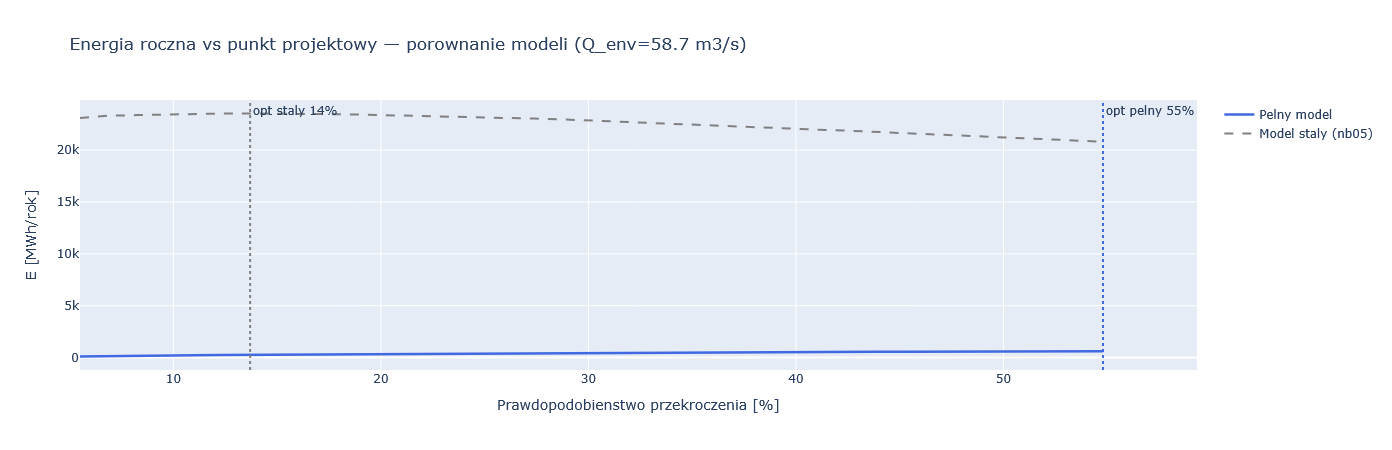

In [8]:
# Sweep dnia instalacyjnego — wolniej niz nb 05 (compute_power liczy duzo)
# wiec idziemy z wiekszym krokiem. Zachowujemy Q_env we wszystkich wariantach.
days = np.arange(20, 201, 5)
rows = []
for d in days:
    Q_total = float(Q_sorted[d - 1])
    Q_d = Q_total / N_TURBINES
    H_d = float(H_gross[d - 1])

    # Pelny model (z Q_env)
    r_full = compute_power(Q_sorted, H_gross, Q_d, N_TURBINES,
                           turbine_type, loss_fns=loss_fns, H_design=H_d, Q_env=Q_ENV)
    E_full = annual_energy(r_full)
    P_inst = 998 * 9.81 * Q_d * H_d * turbine_type.eta_peak / 1000.0 * N_TURBINES

    # Model staly (nb05) — tez z Q_env, zeby porownanie bylo uczciwe
    r_simple = compute_power_constant_eta(
        Q_sorted, H_gross, Q_total, N_TURBINES,
        Q_min_fraction=turbine_type.Q_ratio_min, eta_total=0.848, Q_env=Q_ENV)
    E_simple_d = annual_energy(r_simple)

    rows.append({
        'install_day': d,
        'install_pct': round(d / len(Q_sorted) * 100, 1),
        'Q_total_design': Q_total,
        'P_installed_kW': P_inst,
        'E_full_MWh': E_full,
        'E_simple_MWh': E_simple_d,
        'roznica_pct': (E_full / E_simple_d - 1) * 100 if E_simple_d > 0 else 0,
    })
df_sweep = pd.DataFrame(rows)

best_full = df_sweep.loc[df_sweep['E_full_MWh'].idxmax()]
best_simple = df_sweep.loc[df_sweep['E_simple_MWh'].idxmax()]
print(f'Optimum pelnego modelu:   dzien {int(best_full["install_day"])} '
      f'({best_full["install_pct"]:.0f}%), E = {best_full["E_full_MWh"]:.0f} MWh, '
      f'P = {best_full["P_installed_kW"]:.0f} kW')
print(f'Optimum modelu stalego:   dzien {int(best_simple["install_day"])} '
      f'({best_simple["install_pct"]:.0f}%), E = {best_simple["E_simple_MWh"]:.0f} MWh, '
      f'P = {best_simple["P_installed_kW"]:.0f} kW')

# Wykres
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_sweep['install_pct'], y=df_sweep['E_full_MWh'],
    mode='lines', name='Pelny model', line=dict(color='royalblue', width=2.5)))
fig.add_trace(go.Scatter(x=df_sweep['install_pct'], y=df_sweep['E_simple_MWh'],
    mode='lines', name='Model staly (nb05)',
    line=dict(color='gray', width=2, dash='dash')))
fig.add_vline(x=best_full['install_pct'], line_color='royalblue', line_dash='dot',
    annotation_text=f'opt pelny {best_full["install_pct"]:.0f}%')
fig.add_vline(x=best_simple['install_pct'], line_color='gray', line_dash='dot',
    annotation_text=f'opt staly {best_simple["install_pct"]:.0f}%')
fig.update_layout(
    title=f'Energia roczna vs punkt projektowy — porownanie modeli (Q_env={Q_ENV:.1f} m3/s)',
    xaxis_title='Prawdopodobienstwo przekroczenia [%]',
    yaxis_title='E [MWh/rok]', height=450, hovermode='x unified',
)
fig.show()

---
## Krok 7: Analiza ekonomiczna dla optimum

Dla optymalnego punktu z pelnego modelu liczymy inwestycje, NPV, LCOE i okres zwrotu.

**Prompt do LLM:**
> *"Dla optymalnego punktu (dzien {best_full['install_day']}) policz inwestycje
> `total_investment()` i ekonomie `economic_analysis()` przy cenie 106.5 EUR/MWh
> (= 490 PLN/MWh). Wyswietl tabele wynikow z konwersja na PLN."*

**Uzyte funkcje:** `total_investment`, `economic_analysis`, `EUR_PLN_RATE`.

In [9]:
# Optimum z pelnego modelu
d_opt = int(best_full['install_day'])
Q_opt_total = float(Q_sorted[d_opt - 1])
Q_opt = Q_opt_total / N_TURBINES
H_opt = float(H_gross[d_opt - 1])
P_unit_opt = 998 * 9.81 * Q_opt * H_opt * turbine_type.eta_peak / 1000.0
E_opt = best_full['E_full_MWh']

# Inwestycja
inv = total_investment(
    P_kW=P_unit_opt,
    H=H_opt,
    n_turbines=N_TURBINES,
    turbine_type='kaplan',
    plant_type='run_of_river_small',
)

# Ekonomia
econ = economic_analysis(
    energy_mwh=E_opt,
    investment_eur=inv['total_eur'],
    energy_price_eur_mwh=106.5,  # 490 PLN/MWh / 4.6
    om_fraction=0.025,
    discount_rate=0.06,
    lifetime_years=40,
)

# Wyniki
print(f'=== Analiza ekonomiczna — pelny model, dzien optymalny {d_opt} ===')
print(f'  Moc zainstalowana: {inv["P_total_kW"]:.0f} kW ({N_TURBINES} x {P_unit_opt:.0f} kW)')
print(f'  Energia roczna:    {E_opt:.0f} MWh/rok')
print(f'  Capacity factor:   {E_opt * 1000 / (inv["P_total_kW"] * 8760) * 100:.1f}%')
print()
print(f'  Inwestycja:        {inv["total_eur"]:>12,.0f} EUR = {inv["total_eur"] * EUR_PLN_RATE:>14,.0f} PLN')
print(f'    EM:              {inv["em_eur"]:>12,.0f} EUR ({inv["em_eur"] / inv["total_eur"] * 100:.0f}%)')
print(f'    Roboty bud.:     {inv["civil_eur"]:>12,.0f} EUR ({inv["civil_eur"] / inv["total_eur"] * 100:.0f}%)')
print(f'    Przylacze:       {inv["grid_eur"]:>12,.0f} EUR ({inv["grid_eur"] / inv["total_eur"] * 100:.0f}%)')
print(f'    Inzynieria:      {inv["engineering_eur"]:>12,.0f} EUR ({inv["engineering_eur"] / inv["total_eur"] * 100:.0f}%)')
print(f'  EUR/kW:            {inv["total_per_kw_eur"]:>12,.0f}')
print()
print(f'  Przychod roczny:   {econ["annual_revenue_eur"]:>12,.0f} EUR/rok = '
      f'{econ["annual_revenue_eur"] * EUR_PLN_RATE:>14,.0f} PLN/rok')
print(f'  O&M roczne:        {econ["annual_om_eur"]:>12,.0f} EUR/rok')
print(f'  Dochod netto:      {econ["net_annual_eur"]:>12,.0f} EUR/rok')
print()
print(f'  Okres zwrotu:      {econ["payback_years"]:>12.1f} lat')
print(f'  NPV (r=6%, T=40):  {econ["npv_eur"]:>12,.0f} EUR')
print(f'  LCOE:              {econ["lcoe_eur_mwh"]:>12.1f} EUR/MWh = {econ["lcoe_eur_mwh"] * EUR_PLN_RATE:.0f} PLN/MWh')

=== Analiza ekonomiczna — pelny model, dzien optymalny 200 ===
  Moc zainstalowana: 5832 kW (2 x 2916 kW)
  Energia roczna:    617 MWh/rok
  Capacity factor:   1.2%

  Inwestycja:           5,285,955 EUR =     24,315,391 PLN
    EM:                 2,111,121 EUR (40%)
    Roboty bud.:        2,111,121 EUR (40%)
    Przylacze:            583,172 EUR (11%)
    Inzynieria:           480,541 EUR (9%)
  EUR/kW:                     906

  Przychod roczny:         65,715 EUR/rok =        302,287 PLN/rok
  O&M roczne:             132,149 EUR/rok
  Dochod netto:           -66,434 EUR/rok

  Okres zwrotu:               inf lat
  NPV (r=6%, T=40):    -6,285,545 EUR
  LCOE:                     783.5 EUR/MWh = 3604 PLN/MWh


D:\dydaktyka\2025_2026\EW\notebooks\..\src\costs.py:259: UserWarning: Ogayar & Vidal (2009) validated for P<2 MW; extrapolating to P=2916 kW. Result likely biased low (the formula assumes a single curve; large plants actually benefit from extra economies of scale not captured here).
  em_per_unit = electromechanical_cost(P_kW, H, turbine_type, inflation_factor)


---
## Podsumowanie

W tym notebooku **zlozyliśmy w jedno** wszystkie wczesniejsze modele:

| Krok | Co | Z notebooka |
|------|-----|-------------|
| Krok 1 | Q_sorted, H_gross | 04, 05 |
| Krok 2 | `loss_fns` (straty hydrauliczne) | 06 |
| Krok 3 | Wybor turbiny i wymiarowanie | 07 |
| Krok 4 | `compute_power()` → produkcja | 08 (η_g), `src/production.py` (integrator) |
| Krok 5 | Porownanie pelny vs staly model | 05 vs 06-08 |
| Krok 6 | Optymalizacja punktu projektowego | 05 (rozszerzone) |
| Krok 7 | Analiza ekonomiczna | 09 |

### Kluczowe roznice pelnego modelu vs uproszczonego z nb 05

- **Spad netto** $H_{net}(Q) < H_{brutto}$ — straty rosna z $Q^2$, najwieksze przy szczytach,
- **Sprawnosc turbiny** $\\eta_t$ spada przy czesciowym obciazeniu (Kaplan zachowuje >90% w szerokim zakresie),
- **Sprawnosc generatora** $\\eta_g$ ma maksimum przy ~75-80% $P_n$, **nie 100%**,
- **Rozdzial przeplywu** — przy 2 turbinach lepsza praca przy szczytach (mniej spilla).

### Co dalej (sugestie dla studentow)

1. Zmien typ turbiny (np. propeller, crossflow) i porownaj — niektore odpadaja przez $H_{range}$.
2. Zmien $N_{turbines}$ z 2 na 1, 3, 4 — zobacz wplyw na CF i NPV.
3. Wymien jeden komponent strat (np. usun rurociag — robic kanal otwarty).
4. Sprawdz wrazliwosc na cene energii (90, 110, 130 EUR/MWh).
5. Wprowadz wlasna konfiguracje drogi wodnej i policz wlasny wariant.

**Wszystkie powyzsze zmiany sa kilkulinijkowymi modyfikacjami w odpowiednich krokach.**